In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
%matplotlib inline

In [2]:
path = '/home/annierosen16/data/era5sgp/era5_sl_ET'

files = sorted(glob.glob(f"{path}/*.nc"))

et = xr.open_mfdataset(files, combine="by_coords")

et['valid_time'] = et['valid_time'] - pd.Timedelta(hours=6)

et = et.rename({"valid_time": "time"})

et = et.where(et['time.month'] != 4, drop=True)

In [3]:
## reading in APEs information

with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['date'] = pd.to_datetime(master['date']).dt.date

In [4]:
etdf = et[['e']].to_dataframe().reset_index()

etdf['date'] = pd.to_datetime(etdf['time']).dt.date

etdf = etdf.drop(columns=['number', 'expver'])

In [5]:
etv = etdf.groupby(['date', 'latitude', 'longitude'])['e'].apply(lambda x: x.values).reset_index()

In [6]:
master_with_et = (master.merge(etv, on=['date', 'latitude', 'longitude'], how='inner'))

print(master_with_et.shape)

master_with_et = master_with_et[master_with_et["e"].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)]

print(master_with_et.shape)

(10908747, 23)
(10837448, 23)


In [7]:
dryapes = master_with_et[master_with_et['dryape']==True].reset_index(drop=True)

wetapes = master_with_et[master_with_et['wetape']==True].reset_index(drop=True)

print(dryapes.shape[0], wetapes.shape[0])

279405 220156


In [20]:
# et

dry_et_array = np.stack(dryapes['e'].values)

wet_et_array = np.stack(wetapes['e'].values)

dry_et_composite = np.nanmean(dry_et_array, axis=0) * -1 * 1000 * 24 ## convert from m/hr to mm/day

wet_et_composite = np.nanmean(wet_et_array, axis=0) * -1 * 1000 * 24 ## convert from m/hr to mm/day

dry_et_std = np.nanstd(dry_et_array, axis=0, ddof=1) *-1 * 1000 * 24

wet_et_std = np.nanstd(wet_et_array, axis=0, ddof=1) *-1 * 1000 * 24

dry_et_sem = np.nanstd(dry_et_array, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(dry_et_array), axis=0)) *-1 * 1000 * 24

wet_et_sem = np.nanstd(wet_et_array, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(wet_et_array), axis=0)) *-1 * 1000 * 24

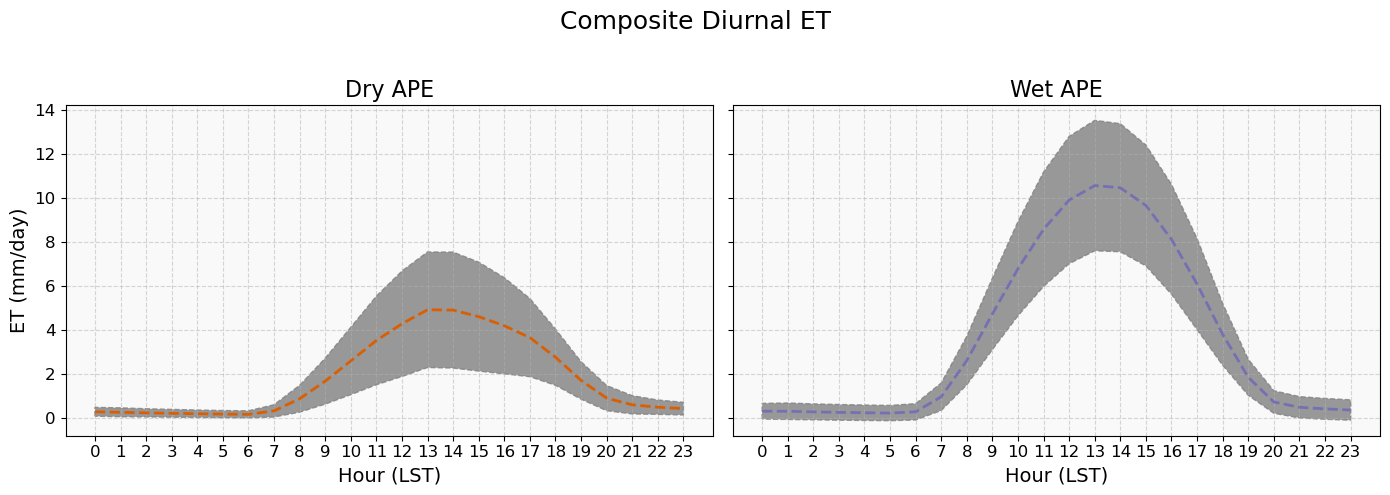

In [21]:
hours = list(range(24))

# Colors (muted palette)

dry_color = '#d95f02'        # Muted orange

wet_color = '#7570b3'        # Muted purple

ci_constant = 1.96

alpha = 0.8

# Create 1x2 subplot layout

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# --- Dry APE ---

axs[0].plot(hours, dry_et_composite, color=dry_color, lw=2, linestyle='--')

# ci shading 

# axs[0].fill_between(hours, 
#                     dry_et_composite - (ci_constant*dry_et_sem), 
#                     dry_et_composite + (ci_constant*dry_et_sem), 
#                     color='grey', 
#                     alpha=alpha, 
#                     linestyle='--')

axs[0].fill_between(hours, 
                    dry_et_composite - dry_et_std, 
                    dry_et_composite + dry_et_std, 
                    color='grey', 
                    alpha=alpha, 
                    linestyle='--')

axs[0].set_title('Dry APE', fontsize=16)

axs[0].set_xlabel('Hour (LST)', fontsize=14)

axs[0].set_ylabel('ET (mm/day)', fontsize=14)

axs[0].grid(True, linestyle='--', alpha=0.5)

axs[0].set_facecolor('#f9f9f9')

# --- Wet APE ---

axs[1].plot(hours, wet_et_composite, color=wet_color, lw=2, linestyle='--')

# axs[1].fill_between(hours, 
#                     wet_et_composite - (ci_constant*wet_et_sem), 
#                     wet_et_composite + (ci_constant*wet_et_sem), 
#                     color='grey', 
#                     alpha=alpha, 
#                     linestyle='--')

axs[1].fill_between(hours, 
                    wet_et_composite - wet_et_std, 
                    wet_et_composite + wet_et_std, 
                    color='grey', 
                    alpha=alpha, 
                    linestyle='--')

axs[1].set_title('Wet APE', fontsize=16)

axs[1].set_xlabel('Hour (LST)', fontsize=14)

axs[1].grid(True, linestyle='--', alpha=0.5)

axs[1].set_facecolor('#f9f9f9')

# Final layout adjustments

for ax in axs.flat:
    
    ax.set_xticks(hours)
    
    ax.tick_params(axis='both', labelsize=12)

fig.suptitle('Composite Diurnal ET', fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [22]:
with open('/home/annierosen16/et_composites_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({'dry': dry_et_composite, 'wet': wet_et_composite}, f)
    
with open('/home/annierosen16/et_composites_1979_2025_std.pkl', 'wb') as f:
    
    pickle.dump({'dry': dry_et_std, 'wet': wet_et_std}, f)